In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,                # reduced for small figure
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.6,
    "legend.fontsize": 5.5,
    "legend.title_fontsize": 5.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,            # ensures editable text in Illustrator
    "ps.fonttype": 42
})

def make_fixed_axis(axis_size=1.25, label_space=0.15):
    """Create figure with a fixed physical data-area size."""
    figsize = (axis_size + label_space, axis_size + label_space)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_box_aspect(1)  # ensures square data region
    return fig, ax

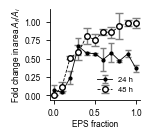

In [6]:
file = pd.read_excel(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0840\PGA-_PGA-EPS-\Extracted thresholded area PGA-_PGA-EPS-.xlsx", nrows = 12)
eps_frac = (file.loc[:,"EPS frac"]).to_numpy()
N1_B = (file.loc[:,"N=1 Before"]).to_numpy()
N1_A = (file.loc[:,"N=1 After"]).to_numpy()
states = ["Before", "After"]
area_before = []
area_after = []
scales = (1/(np.array([45.0667, 46.6667, 44.3556, 44, 44.5333, 44.3556])))**2
c = 0  
for i in range(1, 4):
    for j in range(len(states)):
        col = "N="+str(i)+" "+states[j]
        data = file.loc[:,col] * scales[c]
        if j == 0:
            area_before.append(data.to_numpy())
        elif j==1:
            area_after.append((data.to_numpy()))
        c+=1    

ratios_48 = np.array(area_after) / np.array(area_before)
mean_ratios_48 = np.mean(ratios_48, axis = 0)
std_ratios_48= np.std(ratios_48, axis = 0)
loaded = np.loadtxt(r'C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0840\24 hours area data.txt')
ratio1 = loaded[0]
ratio2 = loaded[1]
ratio3 = loaded[2]
ratios_24 = np.array([ratio1, ratio2, ratio3])
mean_ratios_24 = np.mean(ratios_24, axis=0)
std_ratios_24 = np.std(ratios_24, axis=0)

fig, ax = make_fixed_axis()
frac = np.linspace(0, 1, 11)
ax.errorbar(
    x=frac,
    y=mean_ratios_24,
    yerr=std_ratios_24,
    fmt='o-', 
    color='black',
    ecolor='gray',
    elinewidth=1,
    capsize=2,
    markerfacecolor='black',
    markeredgecolor='black',
    markersize=2,
    label="24 h"
)
ax.errorbar(
    x=frac,
    y=mean_ratios_48,
    yerr=std_ratios_48,
    fmt='o--', 
    color='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    markerfacecolor='white',
    markeredgecolor='black',
    markersize=4,
    label="48 h"
)

ax.set_xlabel("EPS fraction", labelpad=1)
ax.set_ylabel(r"Fold change in area $A_f/A_i$",  labelpad=1)
ax.tick_params(axis='both', which='major', length=3, direction='out', width=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.legend(frameon=False, loc='best')
plt.show()

